# 📞 Customer Churn Prediction using Machine Learning

## 🎯 Project Objective

Customer churn refers to customers who stop using a company's products or services. Predicting customer churn is an important business problem because retaining existing customers is often more cost-effective than acquiring new ones.

The objective of this project is to build Machine Learning classification models that can predict whether a customer is likely to churn or stay based on customer demographics, account details, subscribed services, and billing information.

Throughout this project, we will perform:

- Data Loading and Exploration
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Feature Selection
- Model Building
- Model Evaluation
- Hyperparameter Tuning
- Feature Importance Analysis
- Model Comparison

Finally, we will identify the best-performing model and understand the key factors that influence customer churn.

## 💼 Why is Customer Churn Prediction Important?

Customer churn prediction helps companies identify customers who are likely to leave their services.

By predicting churn early, businesses can:

- Improve customer retention
- Increase customer satisfaction
- Reduce revenue loss
- Design personalized offers for at-risk customers
- Make better business decisions using data

## Step 2: Import Required Libraries

In this step, we import all the libraries required for data manipulation, visualization, preprocessing, model building, evaluation, and hyperparameter tuning.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Train-Test Split
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

### Code Explanation

- **LabelEncoder** converts categorical values into numerical values so that Machine Learning models can understand them.
- **StandardScaler** standardizes numerical features so they have a similar scale.
- **GridSearchCV** helps find the best combination of model parameters to improve performance.

## Step 3: Load & Understand the Dataset

In this step, we load the customer churn dataset into a pandas DataFrame. After loading the data, we display the first few records to understand its structure and verify that it has been loaded correctly.

In [4]:
# Load the dataset
df = pd.read_csv(r"C:\Users\hp\Desktop\Telco-Customer-Churn.csv")

# Display the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Check the shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


The dataset contains **7,043 customer records** and **21 columns**. Each row represents one customer, while each column contains information about the customer's demographics, subscribed services, billing details, or churn status.

In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Statistical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Statistical summary for categorical columns
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [9]:
# Display column names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Step 4: Data Cleaning & Preparation

Before building a Machine Learning model, it is important to clean the dataset. In this step, we will identify and handle data quality issues such as missing values, incorrect data types, and duplicate records to ensure the dataset is ready for further analysis and modeling.

In [10]:
# Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

At first glance, the dataset does not contain any missing (`NaN`) values. However, some columns may contain blank spaces instead of actual missing values. We will identify and handle them in the next step.

In [17]:
# Check blank values in TotalCharges
(df['TotalCharges'] == ' ').sum()

np.int64(0)

The `TotalCharges` column contains **11 blank values**. These blank spaces need to be converted into missing values before changing the column's data 
type. 
Since `TotalCharges` is currently stored as a text (object) column, we will convert it into a numeric data type.

In [18]:
# Replace blank spaces with NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Convert the column to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

### Code Explanation

- Blank spaces are first replaced with `NaN`.
- `pd.to_numeric()` converts the column from text to numeric values.
- The blank values automatically become missing values (`NaN`).

In [19]:
# Check missing values after conversion
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [20]:
# Remove rows with missing values
df.dropna(inplace=True)

# Verify missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Why are we removing these rows?

Only **11 out of 7,043** records contain missing values (less than 0.2% of the dataset). Removing such a small number of rows has a negligible impact on the analysis and is a common practice.
All missing values have been successfully removed, and the dataset is now ready for further analysis.

In [22]:
# Check duplicate records
df.duplicated().sum()

np.int64(0)

### Summary of Data Cleaning

- Checked missing values.
- Identified blank spaces in the `TotalCharges` column.
- Converted `TotalCharges` to numeric.
- Removed rows containing missing values.
- Checked for duplicate records.
- The dataset is now clean and ready for Exploratory Data Analysis (EDA).

## Step 5: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the dataset by identifying patterns, trends, and relationships between different features. These insights help us make better decisions before building Machine Learning models.

### Customer Churn Distribution

Let's examine how customers are distributed between those who stayed and those who churned.

Churn
No     5163
Yes    1869
Name: count, dtype: int64


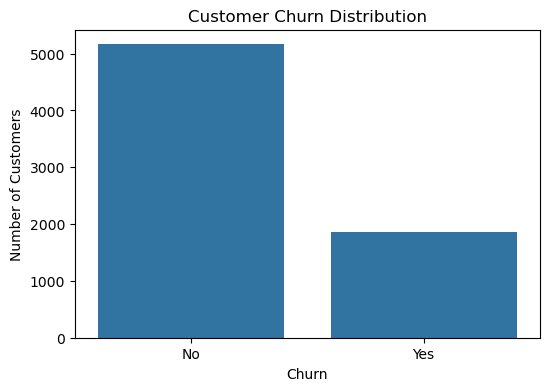

In [27]:
print(df['Churn'].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [28]:
# Percentage distribution of churn
churn_percentage = df['Churn'].value_counts(normalize=True) * 100
print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


Key Observation: Approximately 73% of customers stayed with the company, while 27% churned. The dataset is slightly imbalanced but suitable for classification models.

### Contract Type vs Customer Churn

Let's analyze how different contract types influence customer churn.

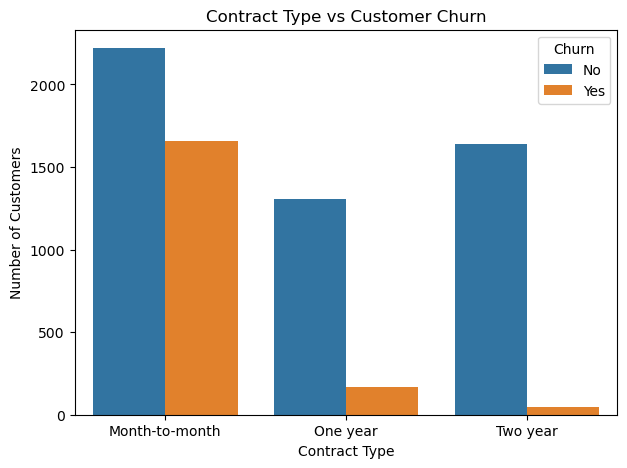

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

**Key Observation:**

Customers with **Month-to-month contracts** have the highest churn rate, while customers with **One year** and **Two year contracts** are more likely to stay with the company. This suggests that longer-term contracts improve customer retention.

### Payment Method vs Customer Churn

Let's analyze whether the customer's payment method has any impact on churn.

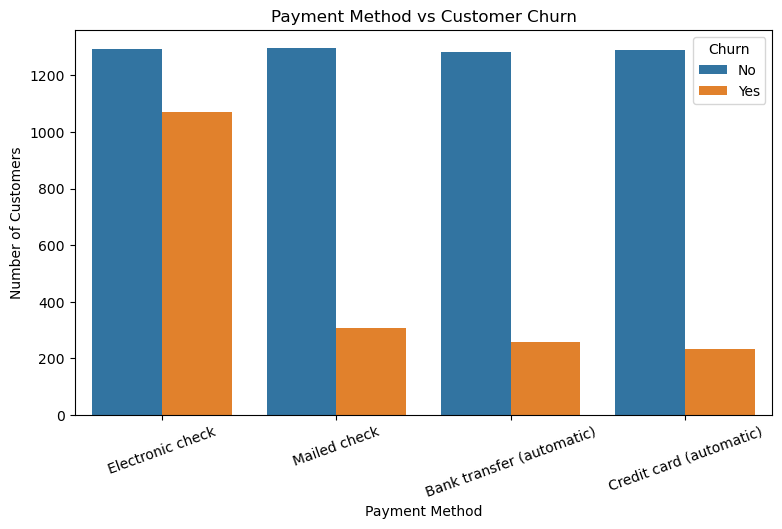

In [35]:
plt.figure(figsize=(9,5))

sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.legend(title="Churn")

plt.show()

**Key Observation:**

Customers using **Electronic Check** show a higher churn rate compared to other payment methods, while customers using automatic payment methods tend to stay with the company.

### Customer Tenure vs Churn

Let's compare the tenure of customers who stayed with those who churned.

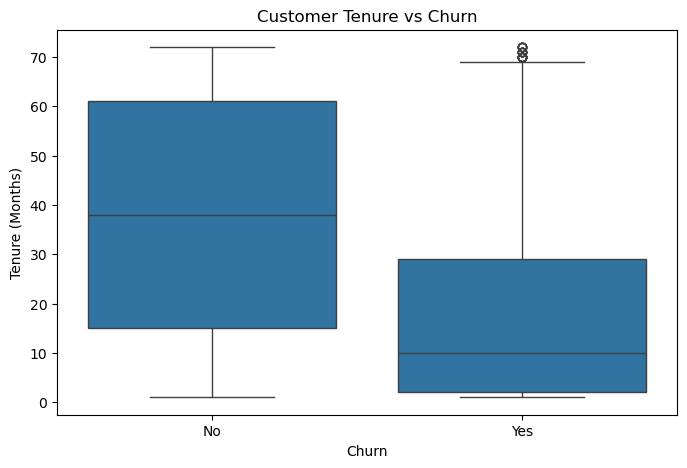

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()                                                   

**Key Observation:**

Customers who churned generally have a lower tenure than those who stayed. This suggests that newer customers are more likely to leave, while long-term customers tend to remain loyal.

### Monthly Charges vs Churn

Let's analyze whether monthly charges influence customer churn.

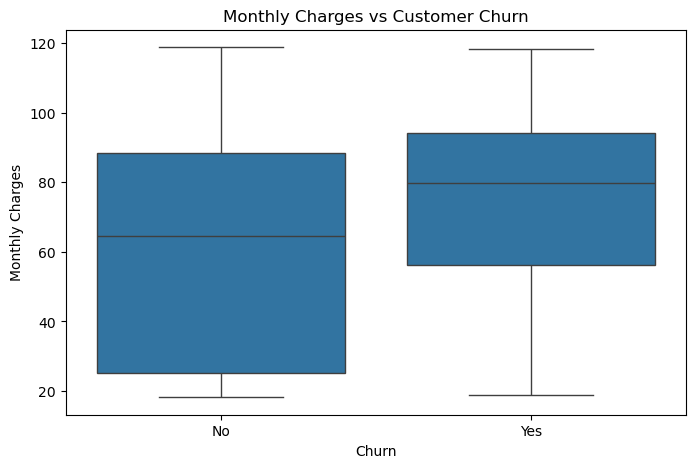

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

**Key Observation:**

Customers who churned tend to have higher monthly charges compared to those who stayed. This indicates that higher service costs may contribute to customer churn.

## Step 6: Feature Engineering

Feature Engineering is the process of creating new features from existing data to improve model performance and capture meaningful business information.

In this project, we will create two new features:
- Total Services
- Tenure Group


### Total Services

Customers who subscribe to more services may show different churn behavior. We create a new feature that counts the total number of services used by each customer.

In [44]:
# List of service columns
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

# Count the number of subscribed services
df['TotalServices'] = (df[service_columns] == 'Yes').sum(axis=1)

# Display the first few rows
df[['customerID', 'TotalServices']].head()

,customerID,TotalServices
0,7590-VHVEG,1
1,5575-GNVDE,3
2,3668-QPYBK,3
3,7795-CFOCW,3
4,9237-HQITU,1


**Code Explanation:**

The expression `(df[service_columns] == 'Yes')` converts each service into `True` or `False`. Using `.sum(axis=1)` counts the number of `True` values for each customer, giving the total number of subscribed services.

### Tenure Group

Customers who stay with a company for different periods may show different churn behavior. We group customers based on their tenure to make the data easier to understand and analyze.

In [45]:
# Create tenure groups
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 48, 72],
    labels=['New Customer', 'Regular Customer', 'Loyal Customer'],
    include_lowest=True
)

# Display the first few rows
df[['customerID', 'tenure', 'TenureGroup']].head()

,customerID,tenure,TenureGroup
0,7590-VHVEG,1,New Customer
1,5575-GNVDE,34,Regular Customer
2,3668-QPYBK,2,New Customer
3,7795-CFOCW,45,Regular Customer
4,9237-HQITU,2,New Customer


### Code Explanation

- `pd.cut()` is used to divide a numerical column into different groups.
- `bins` defines the range for each group.
- `labels` assigns a name to each group.
- `include_lowest=True` makes sure the lowest value is also included in the first group.

## Step 7: Data Preprocessing

Before training the Machine Learning models, we need to prepare the data. In this step, we will remove unnecessary columns and convert categorical features into numerical values.

### Remove Customer ID

The `customerID` column is only used to identify customers. It does not help the model make predictions, so we remove it.

In [46]:
# Remove customerID column
df.drop('customerID', axis=1, inplace=True)

# Display the first 5 rows
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServices,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,New Customer
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,3,Regular Customer
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3,New Customer
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3,Regular Customer
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,New Customer


**Key Observation:**

The `customerID` column has been removed because it is a unique identifier and does not contribute to predicting customer churn.

### Encode Categorical Features

Machine Learning models work with numerical data. We convert all categorical columns into numerical values using Label Encoding.

In [48]:
# Create LabelEncoder object
label_encoder = LabelEncoder()

# Select categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

# Apply Label Encoding
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

# Display first 5 rows
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServices,TenureGroup
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,1,2,29.85,29.85,0,1,1
1,1,0,0,0,34,1,0,0,2,0,...,0,0,1,0,3,56.95,1889.50,0,3,2
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,1,3,53.85,108.15,1,3,1
3,1,0,0,0,45,0,1,0,2,0,...,0,0,1,0,0,42.30,1840.75,0,3,2
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,1,2,70.70,151.65,1,1,1


### Code Explanation

- `select_dtypes(include=['object', 'category'])` selects all categorical columns from the dataset.
- We use a `for` loop to apply **Label Encoding** to each categorical column automatically.
- This saves time and avoids encoding each column one by one.

**Key Observation:**

All categorical features have been converted into numerical values. The dataset is now ready for Machine Learning models.

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   int64  
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   int64  
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   int64  
 17  

**Key Observation:**

All features are now in numerical format, making the dataset ready for feature selection and model building.

## Step 8: Feature Selection & Train-Test Split

In this step, we separate the input features and target variable. Then, we split the dataset into training and testing sets to evaluate the model on unseen data.

In [54]:
# Separate input features and target variable
X = df.drop('Churn', axis=1)
y = df['Churn']


### Code Explanation

- `X` contains all the input features used to train the model.
- `y` contains the target variable (**Churn**) that the model will predict.
- `axis=1` tells pandas to remove the **column** instead of a row.

In [55]:
# Display feature names
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'TotalServices', 'TenureGroup'],
      dtype='object')

In [56]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shape of the split datasets
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (5625, 21)
Testing Features : (1407, 21)
Training Target  : (5625,)
Testing Target   : (1407,)


### Code Explanation

- `test_size=0.2` means 80% of the data is used for training and 20% for testing.
- `random_state=42` ensures the same data split every time the code runs.
- `stratify=y` keeps the same proportion of churned and non-churned customers in both the training and testing sets.

## Step 9: Feature Scaling

Feature Scaling makes numerical features similar in scale. This helps some Machine Learning models, such as Logistic Regression, learn more effectively.

In [57]:
# Create StandardScaler object
scaler = StandardScaler()

# Scale the training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Code Explanation

- `fit_transform()` calculates the scaling values from the training data and applies the transformation.
- `transform()` uses the same scaling values to transform the testing data.
- This prevents data leakage by ensuring that information from the test set is not used during training.

## Step 10: Model Building

We will train different Machine Learning models and compare their performance to find the best model for customer churn prediction.

### Logistic Regression

Logistic Regression is a classification algorithm used to predict whether a customer is likely to churn or not.

In [58]:
# Create the model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

### Model Evaluation

Now, let's check how well the model performs using different evaluation metrics.

In [62]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall   :", round(recall_score(y_test, y_pred_lr), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_lr), 4))

Accuracy : 0.7932
Precision: 0.6285
Recall   : 0.5428
F1 Score : 0.5825


**Key Observation:**

The Logistic Regression model achieved an **accuracy of 79.32%**. It performed well in predicting customers who did not churn, but it missed some customers who actually churned, as shown by the lower Recall (54.28%). We will compare its performance with other models to see if we can improve the results.

### Code Explanation

- **Accuracy** shows the overall correctness of the model.
- **Precision** shows how many predicted churn customers actually churned.
- **Recall** shows how many actual churn customers were correctly identified.
- **F1 Score** gives a balanced measure of Precision and Recall.

### Code Explanation

The classification report shows Accuracy, Precision, Recall, and F1 Score for each class. It gives a detailed summary of the model's performance.

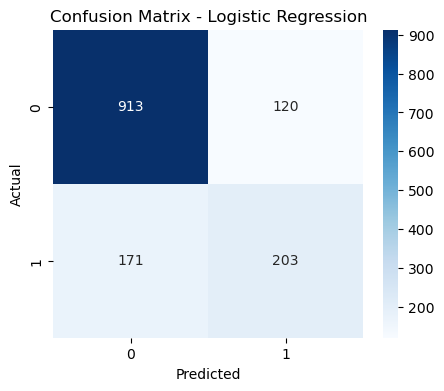

In [64]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Code Explanation

A Confusion Matrix compares the actual values with the predicted values. It helps us understand where the model makes correct predictions and where it makes mistakes.

### Decision Tree

Decision Tree is a classification algorithm that makes predictions by splitting the data into different conditions. It is simple to understand and can capture complex patterns in the data.

In [65]:
# Create the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

In [66]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_dt), 4))
print("Precision:", round(precision_score(y_test, y_pred_dt), 4))
print("Recall   :", round(recall_score(y_test, y_pred_dt), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_dt), 4))

Accuracy : 0.7242
Precision: 0.4831
Recall   : 0.5348
F1 Score : 0.5076


**Key Observation:**

The Decision Tree model achieved an **accuracy of 72.42%**. Compared to Logistic Regression, it gave lower Accuracy, Precision, and F1 Score. This shows that the default Decision Tree model is not performing well on this dataset and may need hyperparameter tuning to improve its performance.

### Random Forest

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to make better predictions. It is often more accurate and stable than a single Decision Tree.

In [67]:
# Create the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

In [68]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 4))

Accuracy : 0.7868
Precision: 0.625
Recall   : 0.4947
F1 Score : 0.5522


## Step 11: Hyperparameter Tuning

Hyperparameter Tuning helps us find the best settings for a Machine Learning model. It can improve the model's performance by trying different combinations of parameters.
We'll tune Random Forest because:

It usually performs better after tuning.
It has several parameters that can be optimized.
It is commonly used in real-world ML projects.

### Random Forest Hyperparameter Tuning

We use **GridSearchCV** to test different parameter values and find the best combination for the Random Forest model.

In [69]:
# Define parameter values
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train the model
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

### Code Explanation

- `param_grid` contains different parameter values to test.
- `GridSearchCV` tries all possible combinations and finds the best one.
- `cv=5` means the training data is divided into 5 parts for cross-validation.
- `scoring='accuracy'` selects the model with the highest accuracy.
- `n_jobs=-1` uses all available CPU cores to make the process faster.

In [70]:
# Display the best parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [71]:
# Best Random Forest model
best_rf = grid_search.best_estimator_

# Make predictions
y_pred_best_rf = best_rf.predict(X_test)

In [72]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_best_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_best_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_best_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_best_rf), 4))

Accuracy : 0.7903
Precision: 0.6357
Recall   : 0.4947
F1 Score : 0.5564


**Key Observation:**

After Hyperparameter Tuning, the Random Forest model showed a small improvement in Accuracy, Precision, and F1 Score. However, Logistic Regression still achieved the best overall performance on this dataset.

## Step 12: Model Comparison

Let's compare the performance of all the Machine Learning models to identify the best one.

In [73]:
# Create model comparison table
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Tuned Random Forest'],
    'Accuracy': [0.7932, 0.7242, 0.7868, 0.7903],
    'Precision': [0.6285, 0.4831, 0.6250, 0.6357],
    'Recall': [0.5428, 0.5348, 0.4947, 0.4947],
    'F1 Score': [0.5825, 0.5076, 0.5522, 0.5564]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7932,0.6285,0.5428,0.5825
1,Decision Tree,0.7242,0.4831,0.5348,0.5076
2,Random Forest,0.7868,0.6250,0.4947,0.5522
3,Tuned Random Forest,0.7903,0.6357,0.4947,0.5564


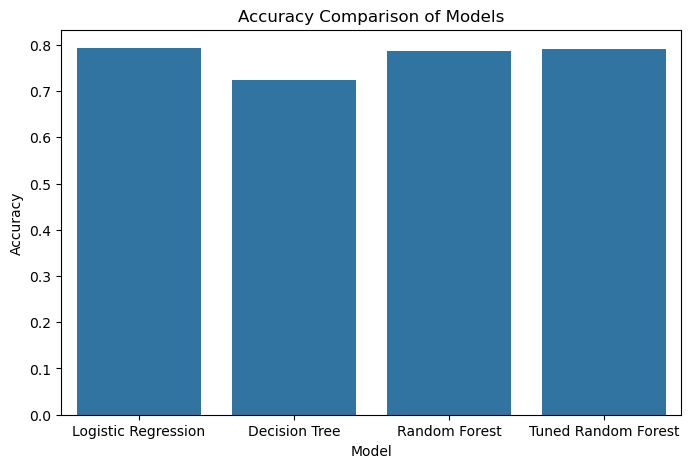

In [74]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=model_comparison,
    x='Model',
    y='Accuracy'
)

plt.title("Accuracy Comparison of Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

**Key Observation:**

Logistic Regression achieved the highest accuracy among all the models. Although Hyperparameter Tuning improved the Random Forest model, Logistic Regression remained the best-performing model for this dataset.

## Step 13: Feature Importance Analysis

Feature Importance helps us understand which features have the biggest impact on the model's predictions. This makes the model easier to understand and explain.

In [76]:
# Get feature importance scores
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 10 important features
feature_importance.head(10)

,Feature,Importance
4,tenure,0.148956
14,Contract,0.140882
18,TotalCharges,0.134648
17,MonthlyCharges,0.130712
8,OnlineSecurity,0.074714
11,TechSupport,0.049404
7,InternetService,0.045821
16,PaymentMethod,0.039904
20,TenureGroup,0.038440
19,TotalServices,0.029498


### Code Explanation

- `feature_importances_` gives the importance score of each feature.
- We create a DataFrame to display the feature names and their importance scores.
- The features are sorted from highest to lowest importance.

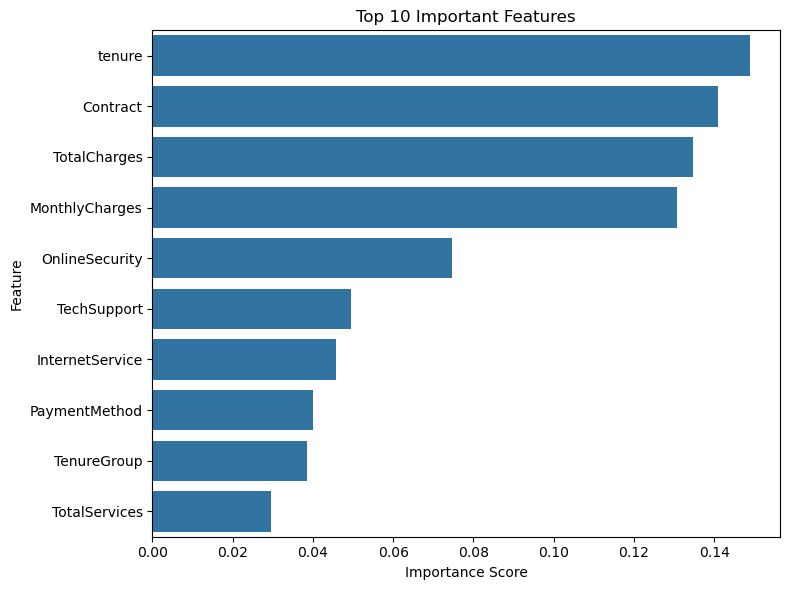

In [78]:
# Plot top 10 important features
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

**Key Observation:**

The most important features for predicting customer churn are **tenure**, **Contract**, **TotalCharges**, and **MonthlyCharges**. The engineered features **TenureGroup** and **TotalServices** also appeared in the top 10, showing that they added useful information to the model.